In [2]:
# Finclub Summer Project 2 (2025)
# Credit Card Behaviour Score Prediction Using Classification and Risk-Based Techniques

# === [1] IMPORT LIBRARIES ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, RocCurveDisplay
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [3]:
# === [2] LOAD DATA ===
train = pd.read_csv("train_dataset_final1.csv")
validate = pd.read_csv("validate_dataset_final.csv")
X = train.drop(columns=["next_month_default"])
y = train["next_month_default"]

In [4]:
# === [3] FEATURE ENGINEERING ===
pay_cols = ['pay_0',  'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
bill_cols = [f'Bill_amt{i}' for i in range(1, 7)]

def engineer_features(df):
    df = df.copy()
    df['utilization_ratio'] = df['AVG_Bill_amt'] / df['LIMIT_BAL']
    df['max_delay'] = df[pay_cols].max(axis=1)
    df['count_delays'] = df[pay_cols].apply(lambda row: (row >= 1).sum(), axis=1)
    df['on_time_pays'] = df[pay_cols].apply(lambda row: (row == -1).sum(), axis=1)
    df['std_bill_amt'] = df[bill_cols].std(axis=1)
    return df

X = engineer_features(X)
validate = engineer_features(validate)

In [5]:
print("Missing values after feature engineering:\n", X.isnull().sum().sort_values(ascending=False).head())


Missing values after feature engineering:
 age            126
marriage         0
Customer_ID      0
sex              0
education        0
dtype: int64


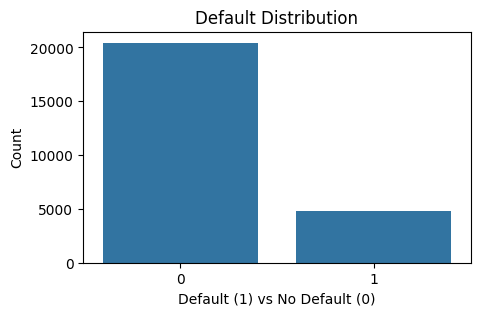

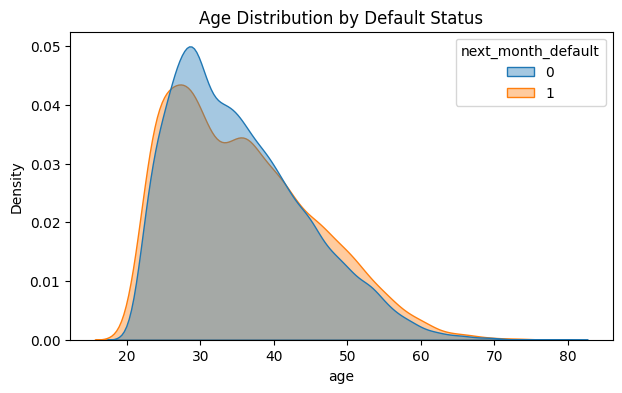

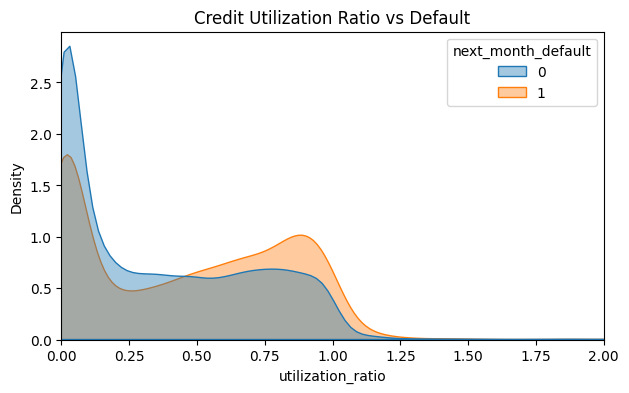

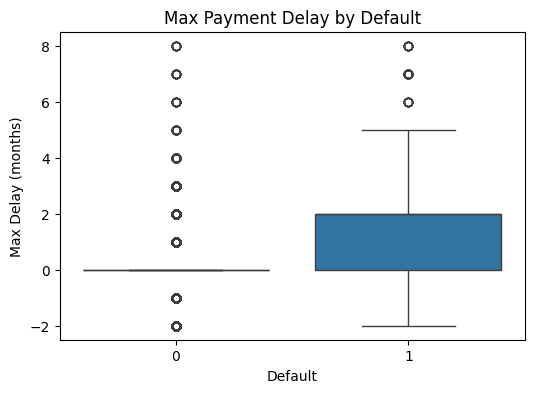

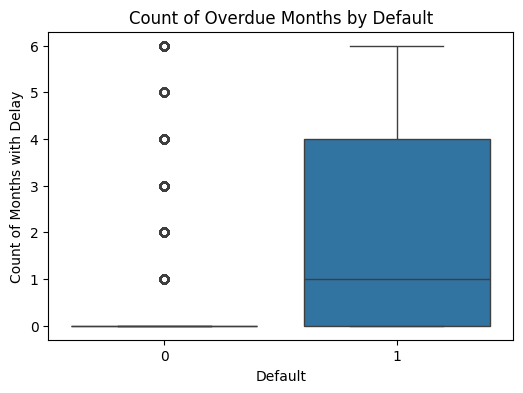

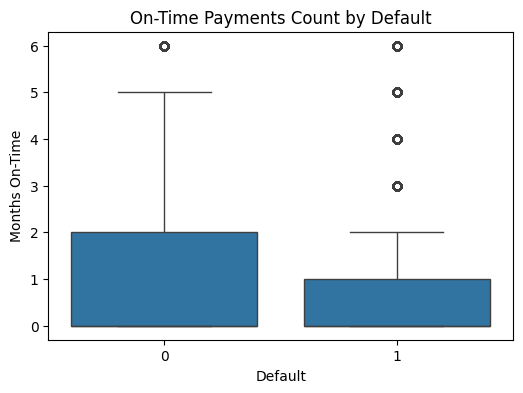

In [6]:


# === [4] EXPLORATORY AND FINANCIAL EDA ===
plt.figure(figsize=(5,3))
sns.countplot(x=y)
plt.title("Default Distribution")
plt.xlabel("Default (1) vs No Default (0)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7,4))
sns.kdeplot(data=X, x='age', hue=y, fill=True, common_norm=False, alpha=0.4)
plt.title("Age Distribution by Default Status")
plt.show()

plt.figure(figsize=(7,4))
sns.kdeplot(data=X, x='utilization_ratio', hue=y, fill=True, common_norm=False, alpha=0.4)
plt.title("Credit Utilization Ratio vs Default")
plt.xlim(0, 2)
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=y, y=X['max_delay'])
plt.title("Max Payment Delay by Default")
plt.ylabel("Max Delay (months)")
plt.xlabel("Default")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=y, y=X['count_delays'])
plt.title("Count of Overdue Months by Default")
plt.ylabel("Count of Months with Delay")
plt.xlabel("Default")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=y, y=X['on_time_pays'])
plt.title("On-Time Payments Count by Default")
plt.ylabel("Months On-Time")
plt.xlabel("Default")
plt.show()

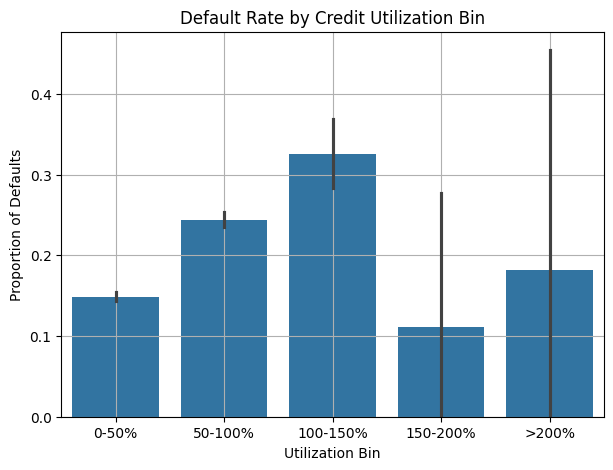

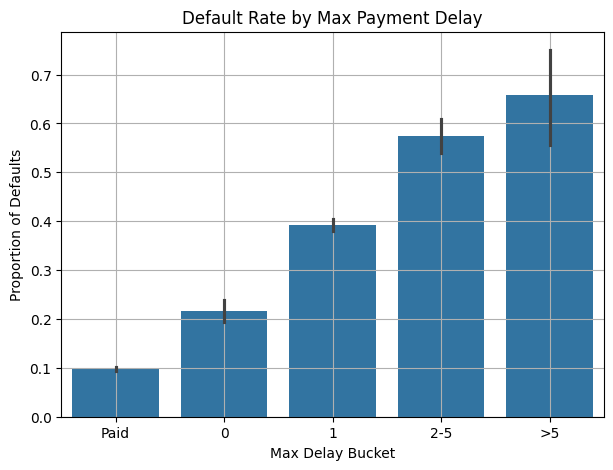

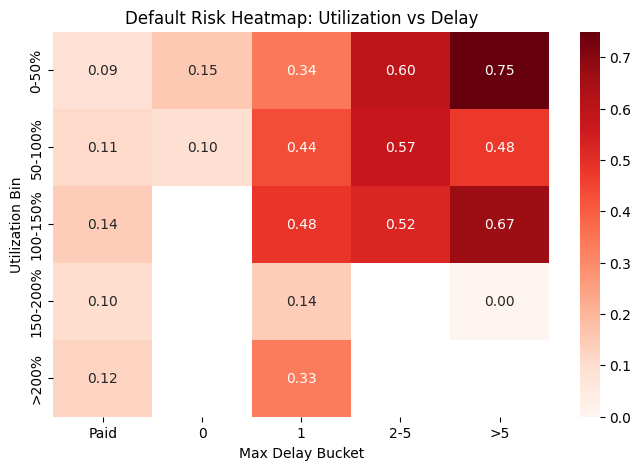

In [7]:
# ADDITIONAL VISUALIZATIONS: RISK STRATIFICATION ===

# 1. Default Rate by Utilization Bins
X_temp = X.copy()
X_temp['default'] = y
X_temp['util_bin'] = pd.cut(X_temp['utilization_ratio'], bins=[0, 0.5, 1.0, 1.5, 2.0, np.inf], labels=["0-50%", "50-100%", "100-150%", "150-200%", ">200%"])

plt.figure(figsize=(7,5))
sns.barplot(x='util_bin', y='default', data=X_temp, estimator=np.mean)
plt.title("Default Rate by Credit Utilization Bin")
plt.ylabel("Proportion of Defaults")
plt.xlabel("Utilization Bin")
plt.grid(True)
plt.show()

# 2. Default Rate by Max Delay Bucket
X_temp['delay_bucket'] = pd.cut(X_temp['max_delay'], bins=[-2, 0, 1, 2, 5, np.inf], labels=["Paid", "0", "1", "2-5", ">5"])

plt.figure(figsize=(7,5))
sns.barplot(x='delay_bucket', y='default', data=X_temp, estimator=np.mean)
plt.title("Default Rate by Max Payment Delay")
plt.ylabel("Proportion of Defaults")
plt.xlabel("Max Delay Bucket")
plt.grid(True)
plt.show()

# 3. Risk Heatmap: Utilization vs Delay
pivot = X_temp.pivot_table(index='util_bin', columns='delay_bucket', values='default', aggfunc='mean')
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap='Reds', fmt=".2f")
plt.title("Default Risk Heatmap: Utilization vs Delay")
plt.ylabel("Utilization Bin")
plt.xlabel("Max Delay Bucket")
plt.show()

In [8]:
# === [5] TRAIN-TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(X.drop(columns=["Customer_ID"]), y, test_size=0.2, stratify=y, random_state=42)

In [9]:
from sklearn.impute import SimpleImputer

# Impute missing values using median strategy
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [10]:
# === [6] SCALING ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)
validate_scaled = scaler.transform(validate.drop(columns=["Customer_ID"]))

In [11]:
# === [7] HANDLE CLASS IMBALANCE ===
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

In [12]:
# === [8] MODEL TRAINING ===
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:,1]
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {
        "report": classification_report(y_test, y_pred, output_dict=True),
        "auc": auc
    }


[LightGBM] [Info] Number of positive: 16352, number of negative: 16352
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003989 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7502
[LightGBM] [Info] Number of data points in the train set: 32704, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


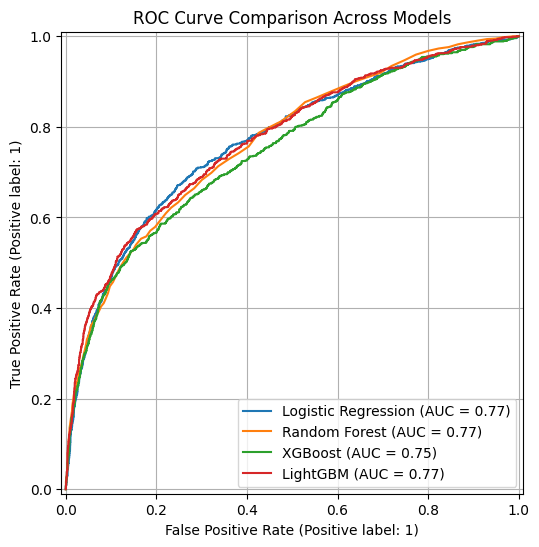

In [13]:

# === [9] MODEL SELECTION: PLOT ROC CURVES ===
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=plt.gca())
plt.title("ROC Curve Comparison Across Models")
plt.grid(True)
plt.show()

In [14]:
# Print classification reports for top 2 models
for name in sorted(results, key=lambda x: results[x]['auc'], reverse=True)[:2]:
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, models[name].predict(X_test_scaled)))
    print("AUC:", results[name]['auc'])


Classification Report for LightGBM:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4088
           1       0.62      0.40      0.49       962

    accuracy                           0.84      5050
   macro avg       0.75      0.67      0.70      5050
weighted avg       0.82      0.84      0.83      5050

AUC: 0.7719543738379354

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.90      0.80      0.85      4088
           1       0.42      0.62      0.50       962

    accuracy                           0.76      5050
   macro avg       0.66      0.71      0.67      5050
weighted avg       0.81      0.76      0.78      5050

AUC: 0.770061505506711


In [15]:
# === [10] BEST MODEL SELECTION ===
best_model = models["XGBoost"]
best_model.fit(X_train_bal, y_train_bal)
y_val_proba = best_model.predict_proba(validate_scaled)[:,1]

In [16]:
# === [11] THRESHOLD TUNING ===
fpr, tpr, thresholds = roc_curve(y_test, best_model.predict_proba(X_test_scaled)[:,1])
precision, recall, pr_thresh = precision_recall_curve(y_test, best_model.predict_proba(X_test_scaled)[:,1])
f1_scores = 2 * precision * recall / (precision + recall + 1e-6)
best_thresh = pr_thresh[np.argmax(f1_scores)]

In [17]:
y_val_pred = (y_val_proba >= 0.5).astype(int)


In [18]:
# === [13] EXPORT PREDICTION FILE ===
submission = pd.DataFrame({
    "Customer": validate["Customer_ID"],
    "next_month_default": y_val_pred
})
submission.to_csv("validation_predictions.csv", index=False)

In [19]:
# === [12] FINAL PREDICTION ON VALIDATION SET ===
y_val_pred = (y_val_proba >= best_thresh).astype(int)

In [20]:
# === [13] EXPORT PREDICTION FILE ===
submission = pd.DataFrame({
    "Customer": validate["Customer_ID"],
    "next_month_default": y_val_pred
})
submission.to_csv("validation_predictions.csv", index=False)

thresholds: (1347,)
tpr: (1347,)
fpr: (1347,)


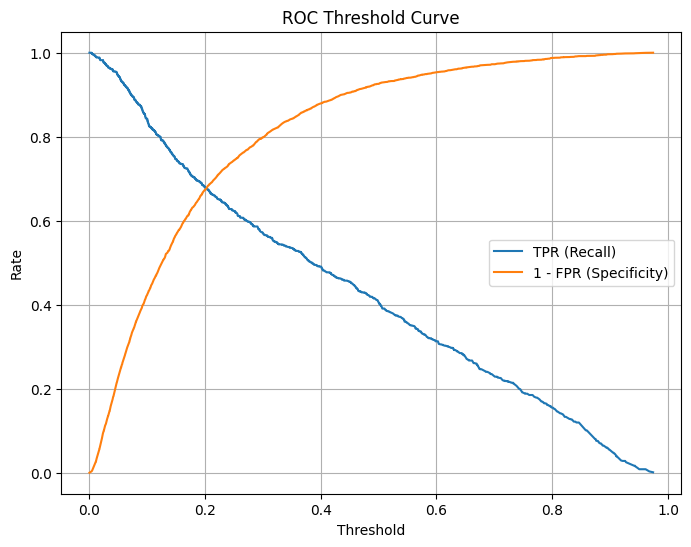

In [22]:
from sklearn.metrics import roc_curve
import numpy as np
import matplotlib.pyplot as plt

# Get ROC values
fpr, tpr, thresholds = roc_curve(y_test, best_model.predict_proba(X_test_scaled)[:, 1])

# Print actual shapes
print("thresholds:", thresholds.shape)
print("tpr:", tpr.shape)
print("fpr:", fpr.shape)

# Align shapes manually
tpr_aligned = tpr[:thresholds.shape[0]]
fpr_aligned = fpr[:thresholds.shape[0]]

# Plot
plt.figure(figsize=(8, 6))
plt.plot(thresholds, tpr_aligned, label="TPR (Recall)")
plt.plot(thresholds, 1 - fpr_aligned, label="1 - FPR (Specificity)")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("ROC Threshold Curve")
plt.legend()
plt.grid(True)
plt.show()
